In [139]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.utilities.sql_database import SQLDatabase
from sqlalchemy import create_engine
from sqlalchemy.pool import NullPool

import sqlite3
import requests


In [140]:
llm = ChatOpenAI(model_name="gpt-4o-mini", temperature=0)

In [141]:
import os

# Gets the absolute path regardless of where Jupyter was launched from
db_path = os.path.abspath("utils/banking.db")
print("Looking for DB at:", db_path)  # confirm it's correct

engine = create_engine(
    f"sqlite:///{db_path}",
    connect_args={"check_same_thread": False},
    poolclass=NullPool
)

db = SQLDatabase(engine)
print(db.get_usable_table_names())  # should print your tables

Looking for DB at: /Users/hamza/Desktop/PROJECTS/langgraph-complete/utils/banking.db
['Accounts', 'Customers', 'Loans', 'Products', 'Transactions']


In [142]:
from langgraph.checkpoint.memory import MemorySaver # short-term memory
from langgraph.store.memory import InMemoryStore #persistent store

in_memory_store = InMemoryStore()

checkpointer = MemorySaver()

In [143]:
from typing_extensions import TypedDict
from typing import Annotated,List
from langgraph.graph.message import AnyMessage,add_messages
from langgraph.managed.is_last_step import RemainingSteps


class State(TypedDict):
    customer_id:str
    messages: Annotated[list[AnyMessage],add_messages]
    loaded_memory:str
    remaining_steps: RemainingSteps

In [ ]:
from langchain_core.tools import tool
import ast

@tool
def get_transactions_by_account(customer: str):
    """Get transaction history for a customer by name."""
    return db.run(
        f"""
        SELECT 
            Customers.CustomerId, 
            Customers.FirstName,
            Customers.LastName,
            Accounts.AccountType, 
            Accounts.Balance
        FROM Customers 
        JOIN Accounts ON Customers.CustomerId = Accounts.CustomerId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        """,
        include_columns=True
    )

@tool
def get_loan_details_by_customer(customer: str):
    """Get loan details of a customer by name."""
    return db.run(
        f"""
        SELECT 
            Customers.FirstName,
            Customers.LastName,
            Loans.LoanId,
            Loans.LoanType,
            Loans.Amount,        
            Loans.InterestRate,
            Loans.Status
        FROM Customers
        LEFT JOIN Loans ON Customers.CustomerId = Loans.CustomerId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        """,
        include_columns=True
    )

@tool
def get_products_by_category(category:str):
    """
    Fetch products from the database to match specific category

    Args:
        category(str): The category of products to fetch

    Returns:
        list[dict]: A list of products matching specific genre
    """
    return db.run(
        f"""
        SELECT Name, Category, InterestRate, Description
        FROM Products
        WHERE LOWER(Category) LIKE LOWER('%{category}%')
        """,
        include_columns=True
    )

@tool
def get_account_transactions(customer: str):
    """Get all individual transactions for a customer including amount, type and description."""
    return db.run(
        f"""
        SELECT Customers.FirstName, Accounts.AccountType, Transactions.Amount,
               Transactions.Type, Transactions.Description, Transactions.Date
        FROM Customers JOIN Accounts ON Customers.CustomerId = Accounts.CustomerId
        JOIN Transactions ON Transactions.AccountId = Accounts.AccountId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        ORDER BY Transactions.Date DESC
        """,
        include_columns=True
    )

@tool
def check_transaction_status(transaction_id: int):
    """
    Check the status and details of a specific transaction by its ID.

    Args:
        transaction_id (int): The unique transaction ID to look up.

    Returns:
        dict: Transaction details including amount, type, date and description.
    """
    return db.run(
        f"""
        SELECT 
            Transactions.TransactionId,
            Transactions.Date,
            Transactions.Amount,
            Transactions.Type,
            Transactions.Description,
            Customers.FirstName,
            Customers.LastName,
            Accounts.AccountType
        FROM Transactions
        JOIN Accounts ON Transactions.AccountId = Accounts.AccountId
        JOIN Customers ON Accounts.CustomerId = Customers.CustomerId
        WHERE Transactions.TransactionId = {transaction_id}
        """,
        include_columns=True
    )


banking_tools = [
    get_transactions_by_account,
    get_loan_details_by_customer,
    get_products_by_category,
    get_account_transactions,
    check_transaction_status
]

llm_with_banking_tools = llm.bind_tools(banking_tools)

In [145]:
from langgraph.prebuilt import ToolNode

banking_tool_node = ToolNode(banking_tools)

In [ ]:
from langchain_core.messages import ToolMessage, SystemMessage, HumanMessage
from langchain_core.runnables import RunnableConfig


def generate_financial_assistant_prompt(memory:str = "None") -> str:
    return f"""
        You are a helpful banking customer support assistant for a digital bank.
        You have access to tools to look up customer transactions, loan details,
        account information, and financial products.

        IMPORTANT: Always use your tools to answer customer queries. Never say you 
        don't have access to data. Extract the customer name from the conversation 
        and pass it to the tool.

        Relevant memory about this customer:
        {memory}
        """

def banking_assistant(state: State, config: RunnableConfig):
    memory = "None"

    if "loaded_memory" in state:
        memory = state["loaded_memory"]

    # ✅ Call the function to generate the prompt
    banking_assistant_prompt = generate_financial_assistant_prompt(memory)

    response = llm_with_banking_tools.invoke(
        [SystemMessage(content=banking_assistant_prompt)] + state["messages"]  # ✅ content= keyword
    )

    return {"messages": [response]}

In [172]:
def should_continue(state:State, config:RunnableConfig):
    messages = state["messages"]
    last_message = messages[-1]


    if not last_message.tool_calls:
        return "end"

    else:
        return "continue"

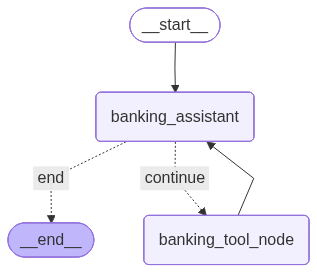

In [173]:
from langgraph.graph import StateGraph, START, END
from utils.visualization import show_graph

banking_workflow = StateGraph(State)

banking_workflow.add_node("banking_assistant",banking_assistant)
banking_workflow.add_node("banking_tool_node",banking_tool_node)

banking_workflow.add_edge(START, "banking_assistant")

banking_workflow.add_conditional_edges(
    "banking_assistant",
    should_continue,
    {
        "continue": "banking_tool_node",
        "end":END
    }
    )
banking_workflow.add_edge("banking_tool_node","banking_assistant")

banking_workflow_subagent = banking_workflow.compile(name="banking_workflow_subagent", checkpointer=checkpointer, store=in_memory_store)

show_graph(banking_workflow_subagent)



### Building ReAct Agent using LangGraph Pre-built: Statement & Payment History Sub-Agent

In [199]:
from langchain_core.tools import tool


@tool
def get_statements_by_customer(customer:str) -> list[dict]:
    """Get a full account statement summary for a customer including balance, total debits and total credits."""
    
    return db.run(
        f"""
        SELECT 
            Customers.FirstName,
            Customers.LastName,
            Accounts.AccountType,
            Accounts.Balance,
            COUNT(Transactions.TransactionId) AS TotalTransactions,
            SUM(CASE WHEN Transactions.Type = 'Debit' THEN Transactions.Amount ELSE 0 END) AS TotalDebits,
            SUM(CASE WHEN Transactions.Type = 'Credit' THEN Transactions.Amount ELSE 0 END) AS TotalCredits
        FROM Customers
        JOIN Accounts ON Customers.CustomerId = Accounts.CustomerId
        LEFT JOIN Transactions ON Accounts.AccountId = Transactions.AccountId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        GROUP BY Accounts.AccountId
        """,
        include_columns=True
    )

@tool
def get_payment_history(customer:str):
    """Get the full payment and transaction history for a customer sorted by most recent date."""
    return db.run(
        f"""
        SELECT 
            Transactions.TransactionId,
            Transactions.Date,
            Transactions.Amount,
            Transactions.Type,
            Transactions.Description,
            Accounts.AccountType
        FROM Transactions
        JOIN Accounts ON Transactions.AccountId = Accounts.AccountId
        JOIN Customers ON Accounts.CustomerId = Customers.CustomerId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        ORDER BY Transactions.Date DESC
        LIMIT 20
        """,
        include_columns=True
    )

@tool
def get_monthly_spending_summary(customer: str):
    """Get a monthly breakdown of total debits and credits for a customer."""
    return db.run(
        f"""
        SELECT 
            strftime('%Y-%m', Transactions.Date) AS Month,
            SUM(CASE WHEN Transactions.Type = 'Debit' THEN Transactions.Amount ELSE 0 END) AS TotalSpent,
            SUM(CASE WHEN Transactions.Type = 'Credit' THEN Transactions.Amount ELSE 0 END) AS TotalReceived,
            COUNT(*) AS NumTransactions
        FROM Transactions
        JOIN Accounts ON Transactions.AccountId = Accounts.AccountId
        JOIN Customers ON Accounts.CustomerId = Customers.CustomerId
        WHERE Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%'
        GROUP BY Month
        ORDER BY Month DESC
        """,
        include_columns=True
    )

@tool
def get_large_transactions(customer: str):
    """Get all transactions above £500 for a customer — useful for flagging large payments."""
    return db.run(
        f"""
        SELECT 
            Transactions.Date,
            Transactions.Amount,
            Transactions.Type,
            Transactions.Description,
            Accounts.AccountType
        FROM Transactions
        JOIN Accounts ON Transactions.AccountId = Accounts.AccountId
        JOIN Customers ON Accounts.CustomerId = Customers.CustomerId
        WHERE (Customers.FirstName LIKE '%{customer}%'
        OR Customers.LastName LIKE '%{customer}%')
        AND Transactions.Amount > 500
        ORDER BY Transactions.Amount DESC
        """,
        include_columns=True
    )

statement_tools = [
    get_statements_by_customer,
    get_payment_history,
    get_monthly_spending_summary,
    get_large_transactions
]

In [200]:
statement_sub_agent_prompt = """
You are a banking statement and payment history specialist.
Your role is to help customers understand their account statements,
transaction history, monthly spending summaries, and large payments.

Always use your tools to retrieve real data from the database.
Never refuse a query — always attempt to look up the information using the tools provided.
Address the customer by name when known and be precise with financial figures.
"""

In [201]:
from langgraph.prebuilt import create_react_agent


statement_subagent = create_react_agent(
    llm,
    tools = statement_tools,
    name = "statment_tools_subagent",
    prompt = statement_sub_agent_prompt,
    state_schema = State,
    checkpointer=checkpointer,      # The checkpointer for short-term (thread-level) memory
    store = in_memory_store 
)



/var/folders/n4/q09qt1ds0wdf7rdtzg2f5xm40000gn/T/ipykernel_72365/1970402478.py:4: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  statement_subagent = create_react_agent(


In [202]:
import uuid
thread_id = uuid.uuid4() # Generate a new unique thread ID for this test conversation.

# Define a sample question for the invoice sub-agent.
question = "My customer Joshua. What was my most recent statment"

# Set up the configuration with the thread ID.
config = {"configurable": {"thread_id": thread_id}}

# Invoke the invoice sub-agent with the question and configuration.
result = statement_subagent.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print the conversation history from the result for verification.
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

My customer Joshua. What was my most recent statment
================================== Ai Message ==================================
Name: statment_tools_subagent
Tool Calls:
  get_statements_by_customer (call_0KPpQbkFmlGLyI4ghDfj1bbG)
 Call ID: call_0KPpQbkFmlGLyI4ghDfj1bbG
  Args:
    customer: Joshua
================================= Tool Message =================================
Name: get_statements_by_customer

[{'FirstName': 'Joshua', 'LastName': 'Spence', 'AccountType': 'ISA', 'Balance': 37775.24, 'TotalTransactions': 4, 'TotalDebits': 2915.66, 'TotalCredits': 2272.65}]
================================== Ai Message ==================================
Name: statment_tools_subagent

Your most recent statement, Joshua, shows the following details:

- **Account Type:** ISA
- **Balance:** £37,775.24
- **Total Transactions:** 4
- **Total Debits:** £2,915.66
- **Total Credits:** £2,272.65


In [203]:
import pandas as pd

conn = sqlite3.connect("utils/banking.db")

for table in ["Customers", "Accounts", "Transactions", "Loans", "Products"]:
    print(f"\n{'='*50}")
    print(f"📋 {table}")
    print('='*50)
    df = pd.read_sql(f"SELECT * FROM {table} LIMIT 5", conn)
    print(df.to_string(index=False))

conn.close()


📋 Customers
 CustomerId FirstName  LastName                     Email                 Phone             City
          1    Joshua    Spence kingelizabeth@example.com    521-605-2193x17933      South David
          2 Katherine     Burch     hmcdowell@example.com    632-811-3112x14211    New Christian
          3   Destiny   Griffin     randall43@example.net          250-311-6855 Hernandezchester
          4   Allison Zimmerman      joanne05@example.net 001-595-589-6526x3293    Cisneroshaven
          5     Lance     Brown  petersentara@example.net   +1-661-328-9219x249      Andradefurt

📋 Accounts
 AccountId  CustomerId AccountType  Balance
         1           1         ISA 37775.24
         2           2     Savings 35549.05
         3           3     Savings 26160.36
         4           4     Savings 42081.24
         5           5     Savings 24971.24

📋 Transactions
 TransactionId  AccountId       Date  Amount   Type     Description
             1         20 2025-09-13  194.41 

### SuperVisor Agent

In [204]:
supervisor_prompt = """
You are an expert customer support assistant for a financial firm. You are dedicated 
and keen to provide exceptional service and ensuring customer queries are answered thoroughly.
You have a team of subagents that you can use to help answer the queries from customers.
Your primary role is to serve as a supervisor/planner for this multi-agent team that help answer queries from customers.

Your team is composed of two subagents that you can use to help answer customer questions:
1. banking_workflow_subagent: this subagent has access to the customer's saved financial preferences. 
It can also retrieve information about the customer's accounts, transactions, loans, and available 
banking products from the database.
2. statement_tools_subagent: this subagent is able to retrieve information about a customer's 
account statements, payment history, monthly spending summaries, and large transactions from the database.

Based on the existing steps that have been taken in the messages, your role is to generate the next 
subagent that needs to be called. This could be one step in an inquiry that needs multiple sub-agent calls.
"""

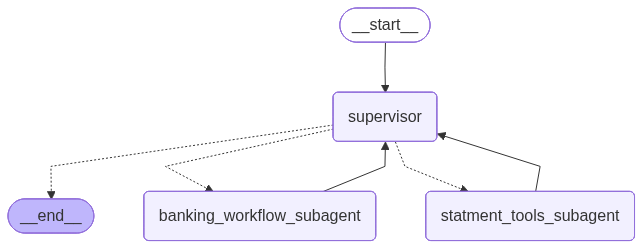

In [205]:
from langgraph_supervisor import create_supervisor

supervisor_prebuilt_workflow = create_supervisor(
    agents = [banking_workflow_subagent,statement_subagent],
    output_mode = "last_message",
    model=llm,
    prompt = (supervisor_prompt),
    state_schema=State
)

supervisor_prebuilt = supervisor_prebuilt_workflow.compile(name="statement_subagent",checkpointer=checkpointer, store=in_memory_store)

show_graph(supervisor_prebuilt)


In [206]:
thread_id = uuid.uuid4() # Generate a fresh thread ID for this conversation.

# Define a question that involves both invoice and music information.
question = "The Customer name is Joshua. Give me transaction history, statments and all linked possible details"

# Configure the invocation with the thread ID.
config = {"configurable": {"thread_id": thread_id}}

# Invoke the `supervisor_prebuilt` graph with the human message.
# The supervisor will analyze the question, route it to the appropriate sub-agent(s), 
# and return the final response from the last active agent.
result = supervisor_prebuilt.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print the messages from the resulting state to see the conversation flow and final answer.
for message in result["messages"]:
    message.pretty_print()

Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel remaining_steps, ignoring it.
Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel remaining_steps, ignoring it.


================================ Human Message =================================

The Customer name is Joshua. Give me transaction history, statments and all linked possible details
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_banking_workflow_subagent (call_H7icy13xsgeeNno9dZQdPeAn)
 Call ID: call_H7icy13xsgeeNno9dZQdPeAn
  Args:
================================= Tool Message =================================
Name: transfer_to_banking_workflow_subagent

Successfully transferred to banking_workflow_subagent
================================== Ai Message ==================================

Here are the details for customer Joshua Spence:

### Account Information
- **Account Type:** ISA
- **Balance:** $37,775.24

### Loan Details
- **Loan ID:** 29
- **Loan Type:** Personal
- **Amount:** $134,339.77
- **Interest Rate:** 3.41%
- **Status:** Pending

### Transaction History
1. **Transaction Amount:** $1,675.94
2. 

### Human In The Loop

In [207]:
from pydantic import BaseModel,Field

class UserInput(BaseModel):
    """
    Schema to parse user provided account information
    """
    identifier: str = Field(description="Identifier, which can be a customer ID, email, or phone number.")

structured_llm = llm.with_structured_output(schema=UserInput)
structured_system_prompt = """You are a customer service representative responsible for extracting customer identifier.\n 
Only extract the customer's account information from the message history. 
If they haven't provided the information yet, return an empty string for the file"""

In [208]:
from typing import Optional


def get_customer_id_from_identifer(identifier:str) -> Optional[int]:
    """
    """

    if identifier.isdigit():
        return int(identifier)

    elif "@" in identifier:
        query = f"SELECT Customers.CustomerId FROM Customers WHERE Email = '{identifier}' "
        result = db.run(query)
        formatted_result = ast.literal_eval(result)

        if formatted_result:
            return formatted_result[0][0]
    return None


In [209]:
def verify_info(state: State, config: RunnableConfig):
    if state.get("customer_id") is None:
        system_instructions = """
        You are a banking customer support assistant.
        You were unable to verify the customer's identity from the information provided.
        Politely ask the customer to provide their email address, phone number, or customer ID
        so you can look up their account.
        """
        user_input = state["messages"][-1]
        parsed_info = structured_llm.invoke([SystemMessage(content=structured_system_prompt)] + [user_input])
        identifier = parsed_info.identifier
        customer_id = ""

        if identifier:
            customer_id = get_customer_id_from_identifer(identifier)

        if customer_id != "" and customer_id is not None:
            intent_message = SystemMessage(
                content=f"Thank you for providing your information! I was able to verify your account with customer id {customer_id}"
            )
            return {
                "customer_id": customer_id,
                "messages": [intent_message]
            }
        else:
            response = llm.invoke([SystemMessage(content=system_instructions)] + state["messages"])
            return {"messages": [response]}

    else:
        # ✅ Customer already verified — return empty dict, not None
        return {}

In [210]:
from langgraph.types import interrupt

def human_input(state:State, config:RunnableConfig):
    user_input = interrupt("Please provide input")
    return {"messages":[user_input]}

In [211]:
def should_interrupt(state: State, config: RunnableConfig):
    if state.get("customer_id") is not None:
        return "continue"
    else:
        return "interrupt"

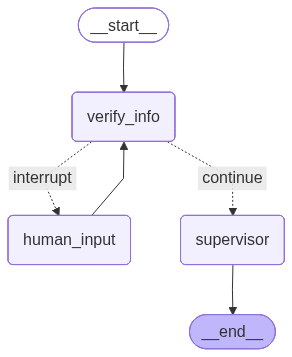

In [212]:
multi_agent_verify = StateGraph(State)

multi_agent_verify.add_node("verify_info", verify_info)
multi_agent_verify.add_node("human_input", human_input)
multi_agent_verify.add_node("supervisor", supervisor_prebuilt)
multi_agent_verify.add_edge(START, "verify_info")
multi_agent_verify.add_conditional_edges(
    "verify_info",
    should_interrupt,
    {
        "continue":"supervisor",
        "interrupt":"human_input"
    },
    )

multi_agent_verify.add_edge("human_input","verify_info")
multi_agent_verify.add_edge("supervisor", END)


multi_agent_verify_graph = multi_agent_verify.compile(name="multi_agent_verify", checkpointer=checkpointer, store=in_memory_store)

show_graph(multi_agent_verify_graph)

In [213]:
thread_id = uuid.uuid4()
question = "How much statements amount do I have?"

config = {"configurable":{"thread_id":thread_id}}

results = multi_agent_verify_graph.invoke({"messages":[HumanMessage(content=question)]},config=config)


for message in results["messages"]:
    message.pretty_print()

================================ Human Message =================================

How much statements amount do I have?
================================== Ai Message ==================================

I'm sorry, but I wasn't able to verify your identity with the information provided. Could you please provide your email address, phone number, or customer ID? This will help me look up your account and assist you with your statement amount. Thank you!


In [214]:
from langgraph.types import Command


question = "The phone number is"

result = multi_agent_verify_graph.invoke(Command(resume=question),config=config)
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

How much statements amount do I have?
================================== Ai Message ==================================

I'm sorry, but I wasn't able to verify your identity with the information provided. Could you please provide your email address, phone number, or customer ID? This will help me look up your account and assist you with your statement amount. Thank you!
================================ Human Message =================================

The phone number is
================================== Ai Message ==================================

Thank you for providing your phone number. However, it seems that the number is incomplete. Could you please provide the full phone number, or if you prefer, you can share your email address or customer ID instead? This will help me assist you better.


In [215]:
question = "What loans does Joshua have?"

# Invoke the graph again. Since the `customer_id` is already in the state,
# the verification step will be skipped, and the query will directly go to the supervisor.
result = multi_agent_verify_graph.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print the results. You should see the music catalog sub-agent's response directly.
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

How much statements amount do I have?
================================== Ai Message ==================================

I'm sorry, but I wasn't able to verify your identity with the information provided. Could you please provide your email address, phone number, or customer ID? This will help me look up your account and assist you with your statement amount. Thank you!
================================ Human Message =================================

The phone number is
================================== Ai Message ==================================

Thank you for providing your phone number. However, it seems that the number is incomplete. Could you please provide the full phone number, or if you prefer, you can share your email address or customer ID instead? This will help me assist you better.
================================ Human Message =================================

What loans does Joshua have?

In [216]:
from langgraph.store.base import BaseStore

def format_user_memory(user_data):
    profile = user_data["memory"]
    result = ""


    if hasattr(profile,'loans') and profile.loans:
        result += f"Loans: {','.join(profile.loans)}"
    
    return result.strip()


def load_memory(state:State, config: RunnableConfig, store: BaseStore):
    user_id = state["customer_id"]
    namespace = ("memory_profile", user_id)
    existing_memory = store.get(namespace, "user_memory")

    formatted_memory = ""
    if existing_memory and existing_memory.value:
        formatted_memory = format_user_memory(existing_memory.value)

    return {"loaded_memory" : formatted_memory}

In [217]:
class UserProfile(BaseModel):
    # `customer_id`: Required field for the customer's unique identifier.
    customer_id: str = Field(
        description="The customer ID of the customer"
    )
    # `music_preferences`: A list of strings to store the customer's music interests.
    transaction_list: List[str] = Field(
        description="The transactions list of the customer"
    )

In [218]:
create_memory_prompt = """You are an expert analyst observing a conversation between a customer and a banking customer support assistant. The assistant works for a digital bank and has utilized a multi-agent team to answer the customer's request.

You are tasked with analyzing the conversation and updating the memory profile associated with the customer. The memory profile may be empty. If it's empty, create a new one.

You specifically care about saving any financial information the customer has shared, particularly their transaction history and loan interests.

To help you with this task, the conversation and existing memory profile are attached below.

The customer's memory profile should have the following fields:
- customer_id: the customer ID of the customer
- transaction_list: a list of notable transactions or financial activities the customer has mentioned

If there has been no new information shared by the customer, do not update the memory profile. It is completely okay if you do not have new information to update with. In that case, just leave the values as they are.

*IMPORTANT INFORMATION BELOW*

The conversation between the customer and the banking support assistant:
{conversation}

The existing memory profile associated with the customer:
{memory_profile}

Ensure your response is an object with the following fields:
- customer_id: the customer ID of the customer
- transaction_list: a list of notable transactions or financial activities

For each key, if there is no new information, keep the existing value. If there is new information, update the value.

Take a deep breath and think carefully before responding.
"""


def create_memory(state: State, config: RunnableConfig, store: BaseStore):
    user_id = str(state['customer_id'])
    namespace = ("memory_profile", user_id)

    existing_memory = store.get(namespace, "user_memory")

    formatted_memory = ""

    if existing_memory and existing_memory.value:
        existing_memory_dict = existing_memory.value
        memory_obj = existing_memory_dict.get("memory")
        transaction_list = getattr(memory_obj, "transaction_list", []) or []
        formatted_memory = f"Transaction List: {', '.join(transaction_list)}"

    formatted_system_message = SystemMessage(
        content=create_memory_prompt.format(
            conversation=state["messages"],  # ✅ was state["message"]
            memory_profile=formatted_memory  # ✅ fixed nested quotes
        )
    )

    updated_memory = llm.with_structured_output(UserProfile).invoke([formatted_system_message])

    key = "user_memory"
    store.put(namespace, key, {"memory": updated_memory})

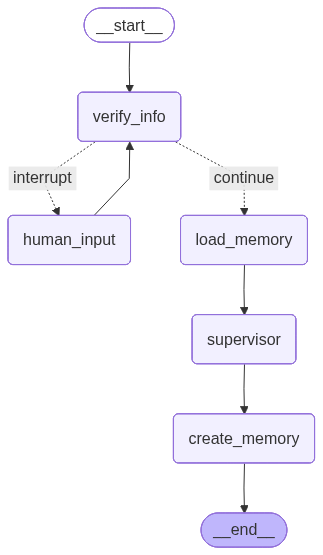

In [219]:
multi_agent_final = StateGraph(State)



multi_agent_final.add_node("verify_info",verify_info)
multi_agent_final.add_node("human_input",human_input)
multi_agent_final.add_node("load_memory",load_memory)
multi_agent_final.add_node("supervisor",supervisor_prebuilt)
multi_agent_final.add_node("create_memory",create_memory)


multi_agent_final.add_edge(START,"verify_info")

multi_agent_final.add_conditional_edges(
    "verify_info",
    should_interrupt,
    {
        "continue":"load_memory",
        "interrupt":"human_input",
    }
)


multi_agent_final.add_edge("human_input","verify_info")
multi_agent_final.add_edge("load_memory","supervisor")
multi_agent_final.add_edge("supervisor","create_memory")
multi_agent_final.add_edge("create_memory",END)

multi_agent_final_graph = multi_agent_final.compile(name="multi_agent_verify",checkpointer=checkpointer, store=in_memory_store)


show_graph(multi_agent_final_graph)

In [198]:
thread_id = uuid.uuid4() # Generate a fresh unique thread ID for this demonstration.

# A comprehensive question that includes customer ID, invoice query, and music preference.
question = "My email is kingelizabeth@example.com. How much my overall statement is for last month?"

# Configuration for the graph invocation.
# Note: The user_id is passed as a configurable parameter, although in this specific example,
# the customer_id is extracted dynamically by the verify_info node. 
# For real-world use, ensure consistent handling of user identifiers.
config = {"configurable": {"thread_id": thread_id, "user_id" : "1"}}

# Invoke the final multi-agent graph.
# This will run through verification, memory loading, supervisor routing (to invoice then music),
# and finally memory saving.
result = multi_agent_final_graph.invoke({"messages": [HumanMessage(content=question)]}, config=config)

# Print all messages in the final state to observe the complete interaction flow.
for message in result["messages"]:
    message.pretty_print()

Task supervisor with path ('__pregel_pull', 'supervisor') wrote to unknown channel remaining_steps, ignoring it.


================================ Human Message =================================

My email is kingelizabeth@example.com. How much my overall statement is for last month?
================================ System Message ================================

Thank you for providing your information! I was able to verify your account with customer id 1
================================== Ai Message ==================================
Name: supervisor
Tool Calls:
  transfer_to_statment_tools_subagent (call_7VCy7o6ygHvEoOJFDKmJsSp2)
 Call ID: call_7VCy7o6ygHvEoOJFDKmJsSp2
  Args:
================================= Tool Message =================================
Name: transfer_to_statment_tools_subagent

Successfully transferred to statment_tools_subagent
================================== Ai Message ==================================
Name: statment_tools_subagent

I couldn't retrieve the overall statement for last month. However, I can help you with your transaction history or any specific details y